Juupyter notebook for simple data analysis of output files from Gaussian, cdftT, pySCF (.cube and density matrix)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

Get transitions used by pySCF (matrix elements of X)

In [309]:
fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_CO/pySCF/X_state_3.npy"
py_X = np.load(fname)
nocc,nvir = np.shape(py_X)

a = np.abs(py_X)
print('pySCF with functionnal blyp')
for i in range(10):
    val = np.max(np.max(a))
    pos = np.argmax(a)
    print(f'transition {int(np.floor(pos/nvir))}->{pos%nvir+nocc} with coef {val:.5f}')
    a[int(np.floor(pos/3)),pos%3]=0
print("")

with np.printoptions(precision=3,suppress=True):
    print(py_X)

pySCF with functionnal blyp
transition 5->8 with coef 0.49709
transition 4->7 with coef 0.49709
transition 5->7 with coef 0.05388
transition 4->8 with coef 0.05388
transition 3->8 with coef 0.00000
transition 3->7 with coef 0.00000
transition 6->8 with coef 0.00000
transition 4->9 with coef 0.00000
transition 6->7 with coef 0.00000
transition 2->8 with coef 0.00000

[[-0.     0.    -0.   ]
 [ 0.     0.    -0.   ]
 [ 0.     0.     0.   ]
 [ 0.     0.     0.   ]
 [ 0.497  0.054  0.   ]
 [ 0.054 -0.497 -0.   ]
 [ 0.     0.     0.   ]]


compare 2 RDM

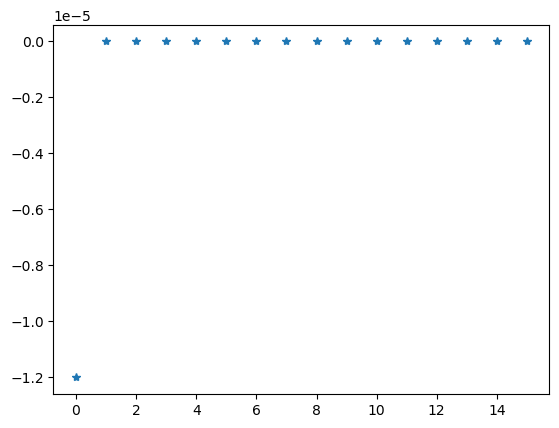

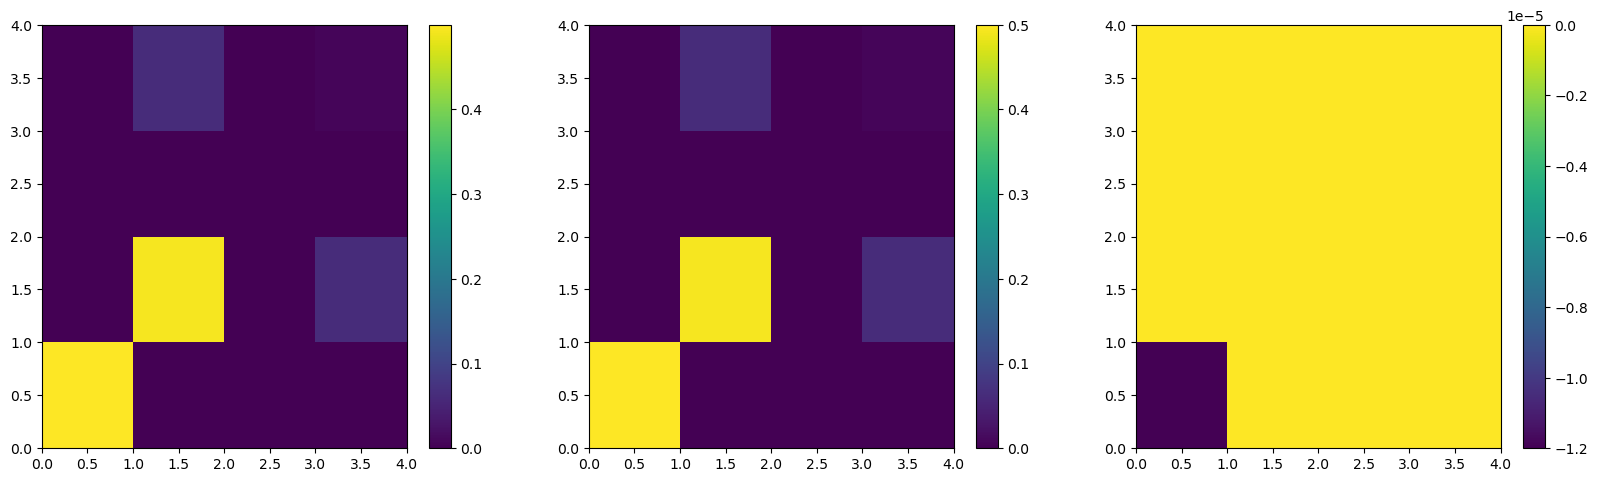

[[0.5   0.    0.    0.   ]
 [0.    0.492 0.    0.061]
 [0.    0.    0.    0.   ]
 [0.    0.061 0.    0.008]]


In [ ]:
f1 = open("/home/atourneur/Documents/CdftT/test_ambroise/test_CO/test_transition/H2/cpp_Gamma_state1_RDM.cdftt")
f2 = open("/home/atourneur/Documents/CdftT/test_ambroise/test_CO/test_transition/H2/cpp_X_state1_RDM.cdftt")
Nmo = 4          # number of molecular orbitals i.e. size of matrix

tokens = f1.read().split()
data = []
for idx, token in enumerate(tokens):
    if idx >=2 :
        row = token
        data.append(row)
RDM_X = np.array(data[0:Nmo**2],dtype=float)

tokens = f2.read().split()
data = []
for idx, token in enumerate(tokens):
    if idx >=2 :
        row = token
        data.append(row)
RDM_Gamma = np.array(data[0:Nmo**2],dtype=float)

plt.plot(RDM_X-RDM_Gamma,"*")
plt.show()

RDM_X.resize((Nmo,Nmo))
RDM_Gamma.resize((Nmo,Nmo))

fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(20,5.5))#,subplot_kw={"projection": "3d"})
plot1 = ax[0].pcolormesh(RDM_X)
plt.colorbar(plot1)
plot2 = ax[1].pcolormesh(RDM_Gamma)
plt.colorbar(plot2)
plot3 = ax[2].pcolormesh(RDM_X-RDM_Gamma)
plt.colorbar(plot3)
plt.show()

CUBE file comparison

In [301]:
f = open("/home/atourneur/Documents/CdftT/test_ambroise/test_CO/test_transition/H2/cpp_Gamma_transition_state0_state3.cube")
#f = open("/home/atourneur/Documents/CdftT/test_ambroise/test_CO/clean_test/noSCF/CO_GS.cube")
tokens = f.read().split()

data = []
for idx, token in enumerate(tokens):
    if idx >=32 :
        row = token
        data.append(row)

densitycpp = np.array(data,dtype=float)/np.sqrt(0.70171**2+0.08716**2)
#f = open("/home/atourneur/Documents/CdftT/test_ambroise/test_CO/clean_test/noSCF/CO_Ex1.cube")
f = open("/home/atourneur/Documents/CdftT/test_ambroise/test_CO/test_transition/pySCF/rho_tr_tda_state3.cube")
#f = open("/home/atourneur/Documents/CdftT/test_ambroise/test_CO/out_openshell/cpp_X_transition_state1_state3.cube")
tokens = f.read().split()

data = []
for idx, token in enumerate(tokens):
    if idx >=41 :
        row = token
        data.append(row)

densitygaussian = np.array(data,dtype=float)*2

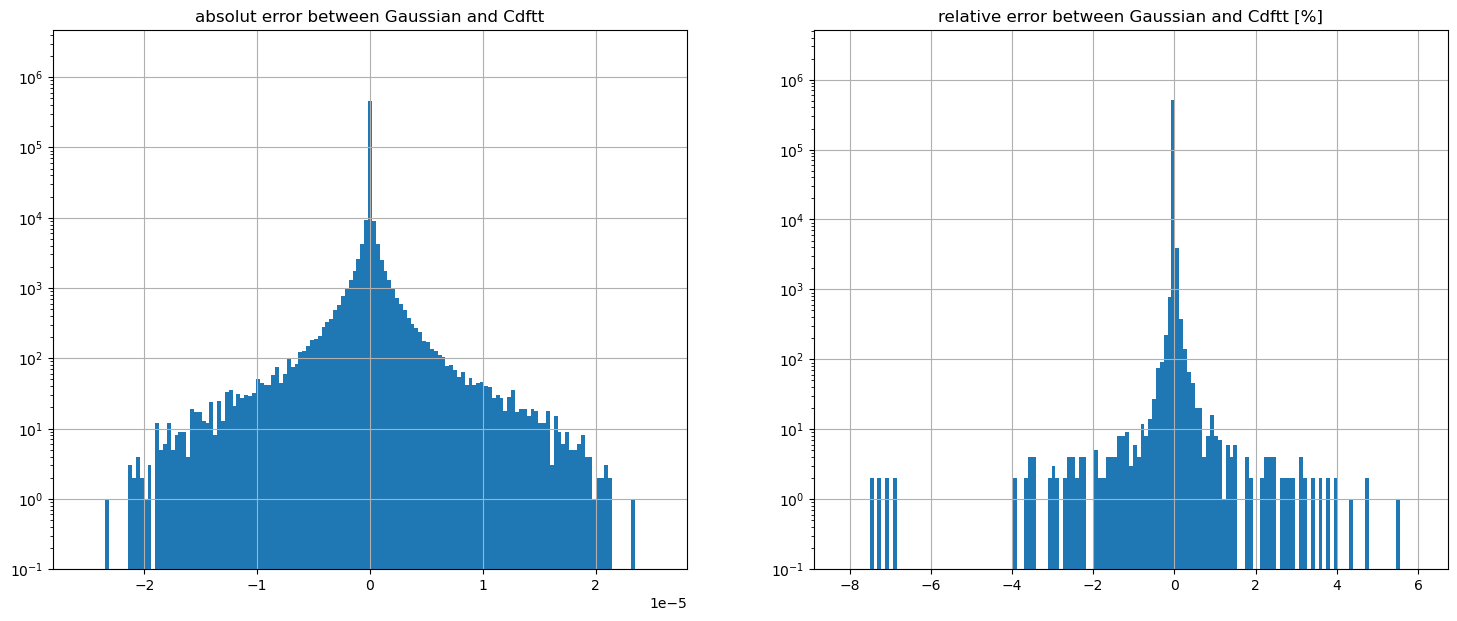

In [302]:
#densitycpp = np.abs(densitycpp)
#densitygaussian[densitygaussian<10e-10] = 10e-10
#densitycpp[densitycpp<10e-10] = 10e-10
err = (densitycpp - densitygaussian)
rel_err = err/densitygaussian*100

bins     = np.linspace(np.min(err),np.max(err),150)*1.1#np.linspace(-1,1,250)*1e-6*1
rel_bins = np.linspace(np.min(rel_err),np.max(rel_err),150)*1.1#np.linspace(-1,1,250)*1e-3*3
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(18,7))#,subplot_kw={"projection": "3d"})
plot1 = ax[0].hist(err,bins=bins)
plot2 = ax[1].hist(rel_err,bins=rel_bins)
ax[0].set_ylim([0.1,plot1[0].max()*10.1])
ax[1].set_ylim([0.1,plot2[0].max()*10.1])
ax[0].set_title("absolut error between Gaussian and Cdftt")
ax[1].set_title("relative error between Gaussian and Cdftt [%]")
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[0].grid()
ax[1].grid()
plt.show()


-0.5760382171799329
-0.576032


(array([4.000e+00, 1.400e+01, 2.800e+01, 2.050e+02, 5.116e+05, 5.700e+01,
        2.900e+01, 6.000e+00, 0.000e+00, 8.000e+00]),
 array([-205.477, -204.187, -202.896, -201.606, -200.316, -199.025,
        -197.735, -196.445, -195.154, -193.864, -192.573]),
 <BarContainer object of 10 artists>)

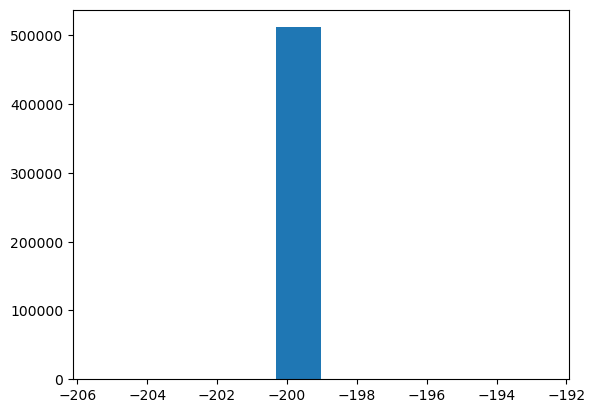

In [269]:
print(min(densitycpp))
print(min(densitygaussian))
plt.hist(rel_err)

Read .fchk

In [54]:
#f = open("/home/atourneur/Documents/CdftT/test_ambroise/test_CO/clean_test/input/CO_TDDFT_STO-3G_TDA_SCF_CUBE.fchk")

fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_CO/clean_test/input/CO_TDDFT_STO-3G_TDA_SCF_CUBE.fchk"
elecDensity  = np.loadtxt(fname=fname, skiprows=230,max_rows=66)
transDensity = np.loadtxt(fname=fname, skiprows=297,max_rows=120)
fchkRDM_Ex1_flat = elecDensity.flatten()[0:55]
fchkRDM_Ex1      = np.zeros(shape=(10,10))

fchkRDM_Ex1[0,:]= fchkRDM_Ex1_flat[0:10]
fchkRDM_Ex1[1,1:]= fchkRDM_Ex1_flat[10:19]
fchkRDM_Ex1[2,2:]= fchkRDM_Ex1_flat[19:27]
fchkRDM_Ex1[3,3:]= fchkRDM_Ex1_flat[27:34]
fchkRDM_Ex1[4,4:]= fchkRDM_Ex1_flat[34:40]
fchkRDM_Ex1[5,5:]= fchkRDM_Ex1_flat[40:45]
fchkRDM_Ex1[6,6:]= fchkRDM_Ex1_flat[45:49]
fchkRDM_Ex1[7,7:]= fchkRDM_Ex1_flat[49:52]
fchkRDM_Ex1[8,8:]= fchkRDM_Ex1_flat[52:54]
fchkRDM_Ex1[9,9:]= fchkRDM_Ex1_flat[54:55]

for p in range(10):
    for q in range(10) :
        if p>q :
            fchkRDM_Ex1[p,q] = fchkRDM_Ex1[q,p]

fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_CO/clean_test/SCF/cpp_core_state1_RDM.cdftt"
cppRDM_Ex1  = np.loadtxt(fname=fname, skiprows=1,max_rows=10)

with np.printoptions(precision=8,suppress=True,linewidth=250):
    print(fchkRDM_Ex1*2)
    #print(cppRDM_Ex1)

fchkRDM_Ex1_flat = elecDensity.flatten()[0:55]
fchkRDM_Ex1      = np.zeros(shape=(10,10))
p = 0
k = 0
l = 10
for p in range(10):
    fchkRDM_Ex1[p,p:]= fchkRDM_Ex1_flat[k:k+l]
    k=k+l
    l-=1

with np.printoptions(precision=8,suppress=True,linewidth=250):
    print(cppRDM_Ex1*2)

[[ 2.1011831  -0.37286593  1.55818148  0.          0.          0.4552114   0.          0.         -0.07447419  1.27857652]
 [-0.37286593  0.06053305 -0.30942543  0.          0.          0.35021943  0.00666972  0.04735363  0.          0.        ]
 [ 1.55818148 -0.30942543 -0.08127335  2.11103886  0.02955597 -0.45699039  0.          0.          0.18975293 -0.4628608 ]
 [ 0.          0.          2.11103886  2.06364076  0.          0.          0.72805099  0.05539322  0.          0.        ]
 [ 0.          0.          0.02955597  0.          0.          1.20164868  0.          0.          0.05539322  0.1156396 ]
 [ 0.4552114   0.35021943 -0.45699039  0.          1.20164868  0.          0.          0.         -0.0411222   1.65628382]
 [ 0.          0.00666972  0.          0.72805099  0.          0.          0.18537603 -0.43374537  0.          0.        ]
 [ 0.          0.04735363  0.          0.05539322  0.          0.         -0.43374537 -0.36200201 -0.06308353  0.38291903]
 [-0.07447419  0

In [10]:
fchkRDM_Ex1 = np.ndarray(shape=(10,10))
fchkRDM_Ex1[0,:] = fchkRDM_Ex1_flat[0:10]

In [ ]:
fname = "/home/atourneur/Documents/CdftT/test_ambroise/test_CO/clean_test/input/CO_TDDFT_STO-3G_TDA_SCF_CUBE.fchk"
MOcoefs    = np.loadtxt(fname=fname, skiprows=157,max_rows=20)
MOcoefs.resize((10,10)) #ligne i -> coefs de la MO i -> MO[i] = sum MOcoefs[i,j]*AO[j]
GSAOdensity_flat =  np.loadtxt(fname=fname, skiprows=199,max_rows=11).flatten()[0:55] #uppertriangular
GSAOdensity      = np.zeros(shape=(10,10))

p = 0
k = 0
l = 10
for p in range(10):
    GSAOdensity[p:,p]= GSAOdensity_flat[k:k+l]
    k=k+l
    l-=1
for p in range(10):
    for q in range(10) :
        if p>q :
            GSAOdensity[q,p] = GSAOdensity[p,q]
#with np.printoptions(precision=8,suppress=True,linewidth=250):
#    print(GSAOdensity)

GSMOdensity = np.zeros(shape=(10,10))
for p in range(10):
    for q in range(10):
        for i in range(10):
            for j in range(10):
                GSMOdensity[p,q] += MOcoefs[i,p]*MOcoefs[j,q]*GSAOdensity[i,j]

with np.printoptions(precision=8,suppress=True,linewidth=250):
    print(GSMOdensity)
                

[[ 0.22492409 -0.00569697  0.24636918 -0.05434985 -0.19928696 -0.70532721 -0.13946757  0.43227973 -0.05861737  0.00662996]
 [-0.00569697  0.31784983  0.83102068  0.33985625  1.13009188  1.33646486 -2.34068958  0.53038921  0.49901722  1.19554922]
 [ 0.24636918  0.83102068 -0.56967647  0.20390292  1.21820134  0.37274047 -1.14920533  0.42346675  0.48720145  0.96954248]
 [-0.05434985  0.33985625  0.20390292  0.          0.44260022  0.02013391 -0.2774083   0.48720145  0.          0.30440395]
 [-0.19928696  1.13009188  1.21820134  0.44260022  1.70068234  1.24750289 -2.17774802  0.67192756  0.68115297  1.40670623]
 [-0.70532721  1.33646486  0.37274047  0.02013391  1.24750289  1.56090316  0.00814386  0.48164887  0.08524789 -0.25882447]
 [-0.13946757 -2.34068958 -1.14920533 -0.2774083  -2.17774802  0.00814386  5.30099813 -0.82453001 -0.63196407 -0.01644408]
 [ 0.43227973  0.53038921  0.42346675  0.48720145  0.67192756  0.48164887 -0.82453001 -0.31478233  0.68177064  0.6688117 ]
 [-0.05861737  0

In [43]:
MOcoefs.resize((10,10))
print(MOcoefs)

[[ 5.696e-04 -1.040e-02  0.000e+00  0.000e+00 -9.152e-03  9.933e-01
   3.183e-02  0.000e+00  0.000e+00 -7.553e-03]
 [ 9.917e-01  3.458e-02  0.000e+00  0.000e+00  8.475e-03  3.806e-04
  -1.045e-02  0.000e+00  0.000e+00  3.140e-03]
 [-1.267e-01  2.366e-01  0.000e+00  0.000e+00  1.769e-01 -2.196e-01
   7.493e-01  0.000e+00  0.000e+00 -2.560e-01]
 [ 1.686e-01 -5.582e-01  0.000e+00  0.000e+00 -8.326e-02 -1.448e-01
   6.918e-01  0.000e+00  0.000e+00  5.926e-01]
 [ 0.000e+00  0.000e+00  0.000e+00  4.736e-01  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  7.739e-01  0.000e+00]
 [ 0.000e+00  0.000e+00  4.736e-01  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  7.739e-01  0.000e+00  0.000e+00]
 [-1.780e-01  7.860e-01  0.000e+00  0.000e+00 -5.343e-01 -3.482e-03
   3.712e-02  0.000e+00  0.000e+00  4.596e-01]
 [ 0.000e+00  0.000e+00  9.151e-01  0.000e+00  0.000e+00  0.000e+00
   0.000e+00 -6.803e-01  0.000e+00  0.000e+00]
 [ 0.000e+00  0.000e+00  0.000e+00  9.151e-01  0.000e+00  0.000e+00
   0.000e+00

In [ ]:
#MO coefficients from .log
row1 = [-18.70739,-9.76257,-1.01735,-0.40129,-0.33167,-0.33167,-0.20244,0.05282,0.05282,0.63514]
row2 = [-0.01040   0.03458   0.23662  -0.55816   0.00000,]